In [1]:
######################
# Load the fUSI data #
######################

import nibabel as nib
import numpy as np
from pathlib import Path
import tqdm
import matplotlib.pyplot as plt
import os

# Define the base path where your NIfTI files are stored
base_path = Path('/Users/clairenastaskin/data/2025-05-07/sub-Forest001_ses-20250507_task-movements_run-001')  
pwd_file_name = 'sub-Forest001_ses-20250507_task-movements_run-001_pwd.nii.gz'

pwd_path = base_path / pwd_file_name
# Load fUSI nifti file and get data into a numpy array
nifti_img = nib.load(pwd_path)
fusi_data = nifti_img.get_fdata()
fusi_data = np.nan_to_num(fusi_data, nan=0) # no nan
print(fusi_data.shape)

(149, 70, 139, 259)


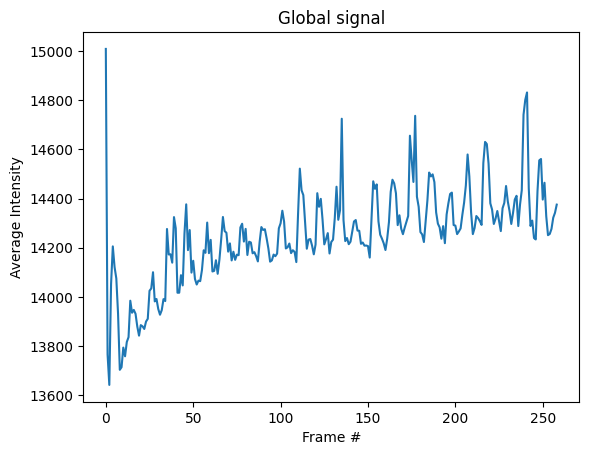

In [2]:
#######################################################################################
#     Display and save power Doppler movie, and display overall intensity over time   #
#######################################################################################

from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.pyplot as plt

movie_path = base_path / "Doppler_movie.mp4"

if not movie_path.exists():
    # Convert to dB scale
    fusi_data_dB = 10*np.log10(fusi_data)
    nnz_idx = fusi_data > np.finfo(fusi_data.dtype).eps
    vmax = np.percentile(fusi_data_dB[nnz_idx], 90)
    vmin = np.percentile(fusi_data_dB[nnz_idx], 10)
    print(vmin)
    print('dynamic range: ', vmax-vmin)
    
    # Save fusi_data_dB as a NIfTI file
    output_filename = pwd_file_name.replace('.nii.gz', '_db.nii.gz')
    output_path = base_path / output_filename
    nifti_img_db = nib.Nifti1Image(fusi_data_dB, nifti_img.affine, nifti_img.header)
    nib.save(nifti_img_db, output_path)

    # Create animation
    fig, ax = plt.subplots()
    cax = ax.imshow(fusi_data_dB[:, fusi_data_dB.shape[1]//2, :, 0].T, cmap="inferno", extent=[0, 60, 92, 25], vmax=vmax+7, vmin=vmin)
    plt.colorbar(cax, ax=ax, label='Intensity (dB)')
    ax.set_title("0")

    ax.set_xlabel("Y (mm)")
    ax.set_ylabel("X (mm)")

    def update(frame):
        cax.set_data(fusi_data_dB[:, fusi_data_dB.shape[1]//2,:, frame].T)
        ax.set_title(f"Frame # {frame}")

    frames_to_plot = range(0, fusi_data_dB.shape[3], 1)
    ani = FuncAnimation(fig, update, frames=frames_to_plot, interval=100)

    # Save the animation
    ani.save(movie_path, writer="ffmpeg")
    plt.close(fig)

# Display the saved movie
from IPython.display import Video
from IPython.display import display
display(Video(str(movie_path), embed=True, width=800, html_attributes="controls autoplay"))


global_signal = np.mean(fusi_data, axis=(0, 1, 2))
fig,ax = plt.subplots()
ax.plot(global_signal)
ax.set_title("Global signal")
ax.set_xlabel("Frame #")
ax.set_ylabel("Average Intensity")
fig.savefig(base_path / "global_signal.png")

Text(0, 0.5, 'Derivative of global signal')

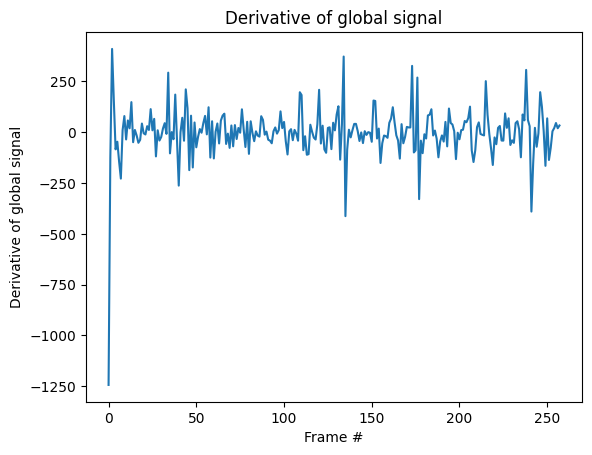

In [3]:
deriv_global_signal = np.diff(global_signal)
fig,ax = plt.subplots()
ax.plot(deriv_global_signal)
ax.set_title("Derivative of global signal")
ax.set_xlabel("Frame #")
ax.set_ylabel("Derivative of global signal")
# ax.set_ylim(-1000, 1000)
# ax.set_xlim(0, 40)



/Users/clairenastaskin/Documents/Anise/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


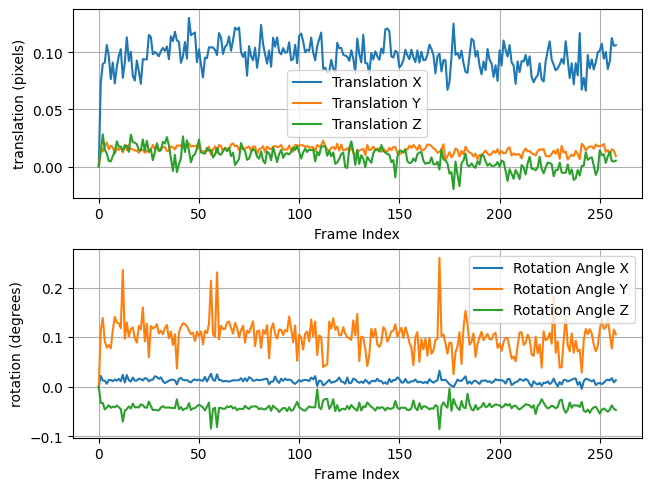

In [4]:
#########################################
#######  Rigid transformation  #########
########################################
import fusi_utils_BIDS as utils

transformation_file = base_path / "rigid_transformations.nii.gz"

if not transformation_file.exists():
    fusi_data_rigid_reg, rigid_transformations = utils.register_3d_image_stack(fusi_data)
    
    # Save rigid transformations to file
    # Create an affine transformation matrix with voxel sizes of 0.15mm 
    # (lambda at 4 MHz ~ 0.30mm. We reconstruct at lambda/2) in x,y,z,t dimensions)
    affine = np.diag([0.17, -0.17, -0.17, 1])
    nib.save(nib.Nifti1Image(rigid_transformations, affine), transformation_file)
    nib.save(nib.Nifti1Image(fusi_data_rigid_reg, affine), base_path / "fusi_data_rigid_reg.nii.gz")
else:
    # Load rigid transformations from file
    rigid_transformations = nib.load(transformation_file).get_fdata()
    fusi_data_rigid_reg = nib.load(base_path / "fusi_data_rigid_reg.nii.gz").get_fdata()

# Plot rigid_transformations
fig, axes = plt.subplots(nrows=2, ncols=1,layout="constrained")
ax_tran=axes[0]
ax_tran.plot(rigid_transformations[0, :], label="Translation X")
ax_tran.plot(rigid_transformations[1, :], label="Translation Y")
ax_tran.plot(rigid_transformations[2, :], label="Translation Z")
ax_tran.set_xlabel("Frame Index")
ax_tran.set_ylabel("translation (pixels)")
ax_tran.legend()
ax_tran.grid(True)
ax_tran.legend()

ax_rot=axes[1]
ax_rot.plot(rigid_transformations[3, :] * 180 / np.pi, label="Rotation Angle X")
ax_rot.plot(rigid_transformations[4, :] * 180 / np.pi, label="Rotation Angle Y")
ax_rot.plot(rigid_transformations[5, :] * 180 / np.pi, label="Rotation Angle Z")
ax_rot.set_xlabel("Frame Index")
ax_rot.set_ylabel("rotation (degrees)")
ax_rot.legend()
ax_rot.grid(True)
ax_rot.legend()

# Save figure
fig.savefig(base_path / "registration.png")
# plt.close()


In [5]:
######################################################################
#     Display and save power Doppler movie after rigid registration  #
######################################################################

movie_file = base_path / "Doppler_movie_after_rigid_registration.mp4"

if not movie_file.exists():
    fusi_data_rigid_reg_dB = 10*np.log10(fusi_data_rigid_reg)
    nnz_idx = fusi_data_rigid_reg > np.finfo(fusi_data_rigid_reg.dtype).eps
    vmax = np.percentile(fusi_data_rigid_reg_dB[nnz_idx], 99.9)
    vmin = vmax - 15 #np.percentile(fusi_data_rigid_reg_dB[nnz_idx], 10)
    print(vmin)
    print('dynamic range: ', vmax-vmin)

    # Create figure and initial plot
    fig, ax = plt.subplots()
    cax = ax.imshow(
        fusi_data_rigid_reg_dB[:, int(fusi_data_rigid_reg_dB.shape[1] / 2), :, 0].T,
        cmap="inferno",
        vmin = vmin,
        vmax = vmax,
        extent=[0, 50, 42, 25],
    )
    ax.set_title("0")

    # Set axis labels
    ax.set_xlabel("Y (mm)")
    ax.set_ylabel("X (mm)")
    plt.colorbar(cax, ax=ax, label='Intensity (dB)')

    def update(frame):
        cax.set_data(
            fusi_data_rigid_reg_dB[:, int(fusi_data_rigid_reg_dB.shape[1] / 2), :, frame].T
        )
        ax.set_title(f"Frame # {frame}")
        return (cax,)

    # Create a list of frames to plot every other frame
    frames_to_plot = range(0, fusi_data_rigid_reg.shape[3], 2)
    ani = FuncAnimation(fig, update, frames=frames_to_plot, interval=100, blit=True)

    # Save the animation as an MP4 file
    ani.save(movie_file, writer="ffmpeg")
    plt.close()
    display(HTML(ani.to_jshtml()))

else:
    # Display the saved movie
    from IPython.display import Video
    from IPython.display import display
    display(Video(str(movie_file), embed=True, width=800, html_attributes="controls autoplay"))



In [6]:
import zarr
zarr_path = Path(base_path, 'flash_analysis/sub-Forest001_ses-20250506_task-movements_run-001/processed-data-xyzt.zarr')
zarr_group = zarr.open_group(zarr_path, mode="r")

singular_values_zarr = zarr_group["singular_values"]
power_doppler_zarr = zarr_group["power_doppler_mapped"]
ensemble_mean_zarr = zarr_group["ensemble_mean_mapped"]
std_zarr = zarr_group["ensemble_std"]
median_zarr = zarr_group["ensemble_median"]

GroupNotFoundError: group not found at path ''

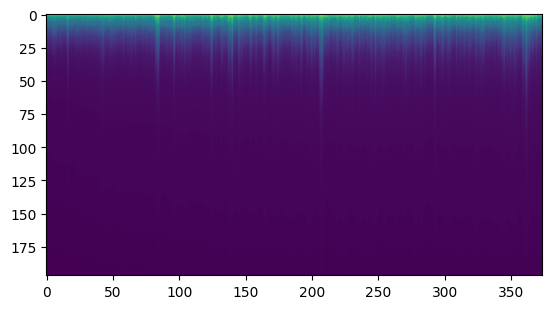

In [7]:
singular_values_zarr.shape

log_singular_values = 20*np.log10(singular_values_zarr)

fig,ax = plt.subplots()
ax.imshow(log_singular_values)


Text(0, 0.5, 'Frame #')

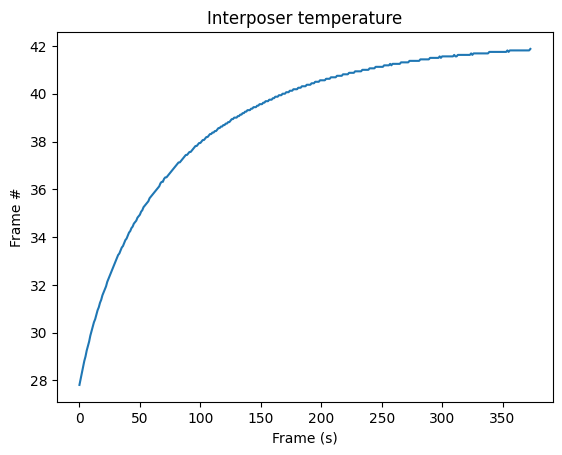

In [8]:
# ################################
# # Plot temperature time course #    
# ################################
import pandas as pd

temp_log_path = base_path / 'logs.csv'
temp_log = pd.read_csv(temp_log_path, sep=',') 
temp_log = temp_log['INTERPOSER_TEMP']

fig,ax = plt.subplots()
ax.plot(temp_log)
ax.set_title('Interposer temperature')
ax.set_xlabel('Frame (s)')
ax.set_ylabel('Frame #')

Text(0.5, 0, 'Frame #')

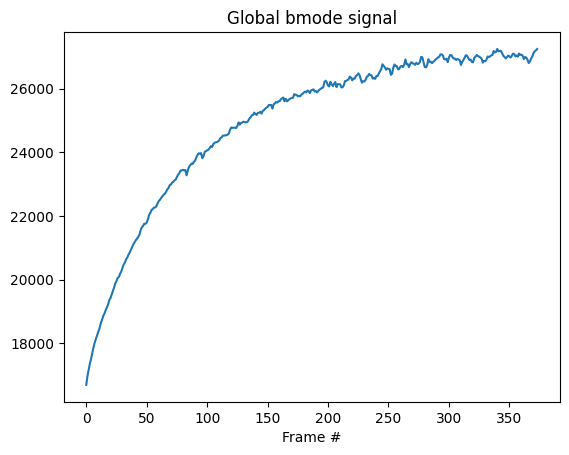

In [9]:
global_bmode_signal = np.abs(np.nanmean(ensemble_mean_zarr, axis=(0, 1, 2)))

fig, ax = plt.subplots()
ax.plot(global_bmode_signal)
ax.set_title("Global bmode signal")
ax.set_xlabel("Frame #")

Text(0.5, 0, 'Frame #')

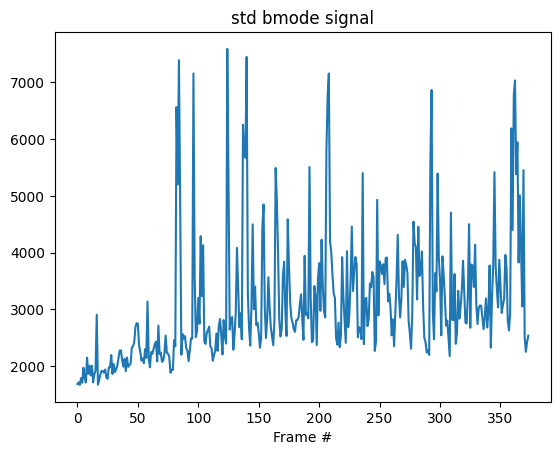

In [10]:
std_signal = np.abs(np.nanmean(std_zarr, axis=(0, 1, 2)))


fig, ax = plt.subplots()
ax.plot(std_signal)
ax.set_title("std bmode signal")
ax.set_xlabel("Frame #")